In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import h5py

from deep_lss.utils import gp_emulator, abc
from msfm.utils import prior

23-03-15 02:18:21     utils.py INF   Loaded the config 
23-03-15 02:18:21   kernels.py INF   Setting the minimum value of the kernel function to 1e-42 for the mpmath library 


In [2]:
preds_file = "/pscratch/sd/a/athomsen/run_files/2023-03-13_06-27-46_resnet_small/preds.h5"

with h5py.File(preds_file, "r") as f:
    print(f.keys())
    
    grid_preds = f["grid/preds"][:]
    grid_cosmos = f["grid/cosmos"][:]
    
    fidu_preds = f["fiducial/preds"][:]
    
print(grid_preds.shape)
print(grid_cosmos.shape)

print(fidu_preds.shape)

<KeysViewHDF5 ['fiducial', 'grid']>
(2500, 16, 2)
(2500, 16, 7)
(800, 2)


# ABC posterior estimation

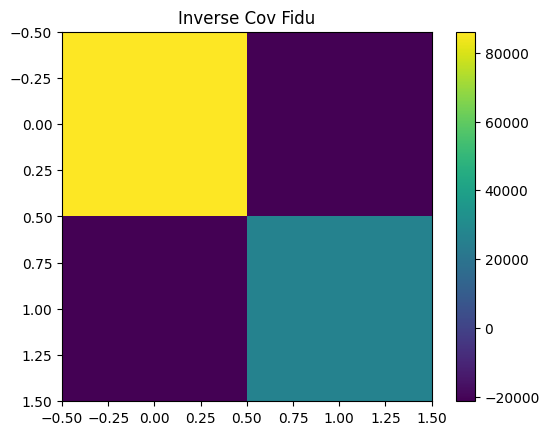

0.9999999999999998


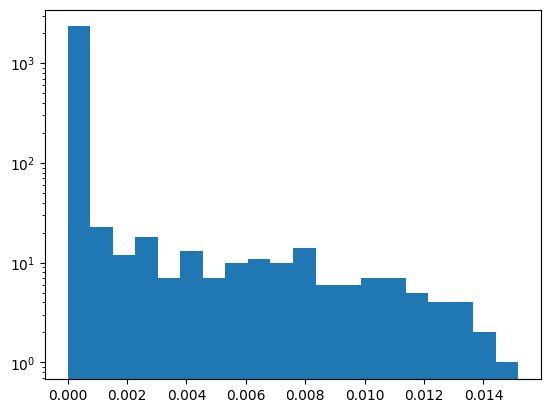

In [3]:
# kernel params
kernel = "sigmoid"
scale=0.4

# get an approximation to the Fisher  matrix
fid_inv_cov = np.linalg.inv(np.cov(fidu_preds, rowvar=False))

# check the inverse covariance
plt.imshow(fid_inv_cov)
plt.colorbar()
plt.title("Inverse Cov Fidu")
plt.show()

# TODO make a distinction between validation and fiducial prediction
obs_pred = np.mean(fidu_preds, axis=0)

# Estimate the posterior and its uncertainties like in the paper
Y_init, posterior = abc.estimate_grid_posterior(
    grid_preds=grid_preds, 
    fid_fisher=fid_inv_cov, 
    obs_pred=obs_pred, 
    scale=scale, 
    kernel=kernel
) 

# check posterior
print(np.sum(posterior))
plt.hist(posterior, log=True, bins=20);

In [4]:
for i in range(grid_cosmos.shape[2]):
    print(i, np.min(grid_cosmos[:,:,i]), "      ", np.max(grid_cosmos[:,:,i]))
    
Om = grid_cosmos[:,0,2]
s8 = grid_cosmos[:,0,4]

0 64.004395        81.98682
1 0.030029297        0.059970703
2 0.10039063        0.49990234
3 0.87009764        1.0699023
4 0.40024415        1.3973144
5 -1.9348828        -0.33381397
6 -2.9970703        2.999977


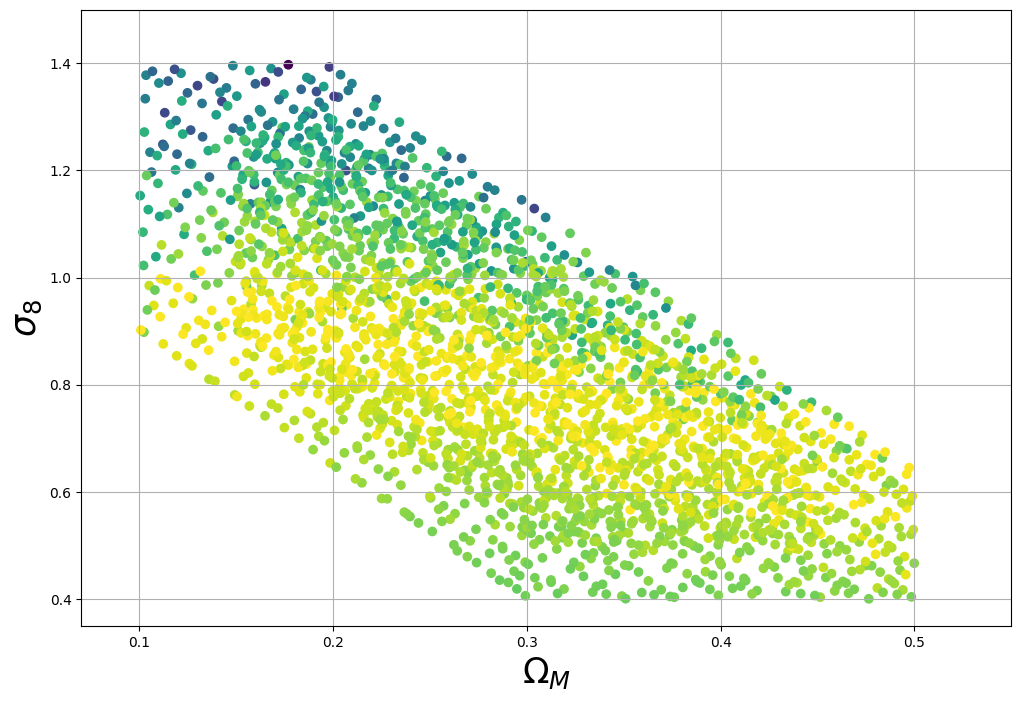

In [5]:
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(Om, s8, c=np.log(posterior))
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

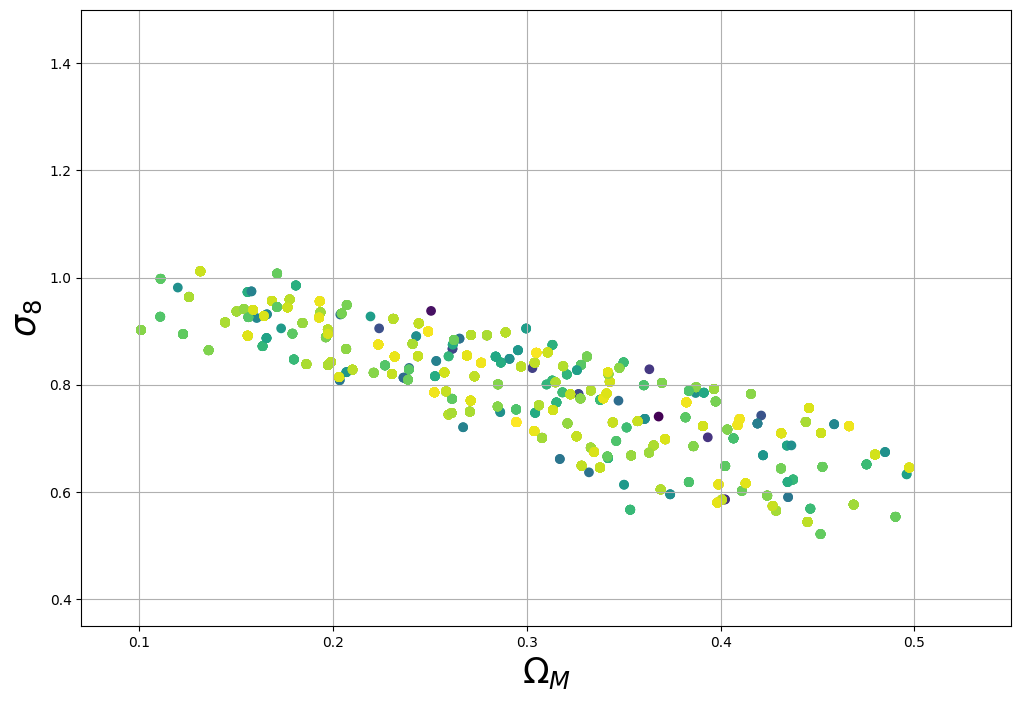

In [6]:
# select a random subset
np.random.seed(11)
probable_indices = np.random.choice(np.arange(len(posterior)), 5000, p=posterior, replace=True)

Om_p, s8_p, post_p = Om[probable_indices], s8[probable_indices], posterior[probable_indices],

fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(Om_p, s8_p, c=np.log(post_p))
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

# GP emulator

In [7]:
X_init = np.stack([Om, s8], axis=-1)
X_init.shape

(2500, 2)

In [16]:
emu = gp_emulator.VGP_Emu(
    objective=None, 
    X_init=X_init, 
    Y_init=Y_init, 
    space=None, 
    num_restarts=1, 
    kern="exponential", 
    max_opt_iter=1000,
    normalize_X=False, 
    normalize_Y=False, 
    mean_only=True, 
    ARD=False, 
    full_restart=False,
    learning_rate=0.1, 
    parameter_noise_scale=0.05,
    minimum_variance=1e-3
)

╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤══════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value            │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪══════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.0              │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.0              │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.num_data            │ Parameter │ Identity       │         │ False       │ ()              │ int32

In [17]:
emu.optimize_model()

Training the VGP model params...


100%|██████████| 1000/1000 [01:41<00:00,  9.84it/s, loss_val=3.87e+5]


In [21]:
predictor = emu.get_noiseless_predictor()

In [30]:
predictions = predictor(X_init)

pred_post = predictions
pred_post -= np.max(pred_post)
pred_post = np.exp(pred_post)
pred_post /= np.sum(pred_post)

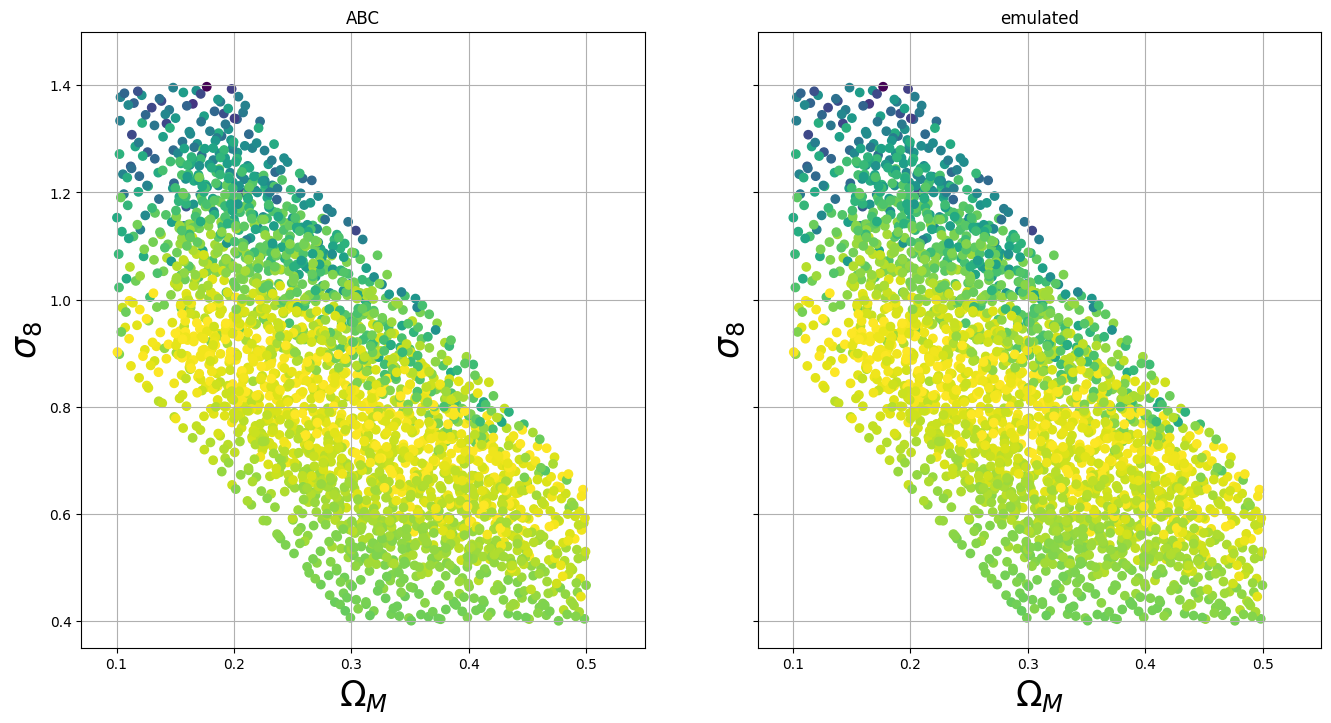

In [34]:
fig, ax = plt.subplots(figsize=(16,8), ncols=2, sharex=True, sharey=True)

# original
ax[0].scatter(Om, s8, c=np.log(posterior))
ax[0].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="ABC")
ax[0].set_xlabel("$\Omega_M$", fontsize=25)
ax[0].set_ylabel("$\sigma_8$", fontsize=25)
ax[0].grid(True)

# emulated
ax[1].scatter(Om, s8, c=np.log(pred_post))
ax[1].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="emulated")
ax[1].set_xlabel("$\Omega_M$", fontsize=25)
ax[1].set_ylabel("$\sigma_8$", fontsize=25)
ax[1].grid(True)


In [35]:
from msfm.utils import prior